In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:

df = pd.read_csv("../data/landing/mi-to-provinces-2013-11-01.csv")

# Basic checks
print(df.head())
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())


              datetime  CellID provinceName  cell2Province  Province2cell
0  2013-11-01 00:00:00       1       MILANO         0.1894         0.0541
1  2013-11-01 00:00:00       1        PAVIA         0.0273            NaN
2  2013-11-01 00:00:00       1       TRENTO         0.0261            NaN
3  2013-11-01 00:00:00       2       MILANO         0.1922         0.0556
4  2013-11-01 00:00:00       2        PAVIA         0.0273            NaN
datetime             str
CellID             int64
provinceName         str
cell2Province    float64
Province2cell    float64
dtype: object
             CellID  cell2Province  Province2cell
count  2.307306e+06   1.407931e+06   1.447630e+06
mean   5.142692e+03   6.463123e-01   6.312888e-01
std    2.782546e+03   2.473941e+00   2.451426e+00
min    1.000000e+00   0.000000e+00   0.000000e+00
25%    2.902000e+03   3.390000e-02   3.090000e-02
50%    5.158000e+03   1.101000e-01   1.050000e-01
75%    7.483000e+03   3.525000e-01   3.347000e-01
max    1.000000e+

In [10]:
df = pd.read_csv("../data/landing/sms-call-internet-mi-2013-11-01.csv")

df.head()


,datetime,CellID,countrycode,smsin,smsout,callin,callout,internet
0,2013-11-01 00:00:00,1,0,0.3521,NaN,NaN,0.0273,NaN
1,2013-11-01 00:00:00,1,33,NaN,NaN,NaN,NaN,0.0261
2,2013-11-01 00:00:00,1,39,1.7322,1.1047,0.5919,0.4020,57.7729
3,2013-11-01 00:00:00,2,0,0.3581,NaN,NaN,0.0273,NaN
4,2013-11-01 00:00:00,2,33,NaN,NaN,NaN,NaN,0.0274


In [11]:
print(df.head())
print("\nData Types:\n", df.dtypes)
print("\nSummary:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())


              datetime  CellID  countrycode   smsin  smsout  callin  callout  \
0  2013-11-01 00:00:00       1            0  0.3521     NaN     NaN   0.0273   
1  2013-11-01 00:00:00       1           33     NaN     NaN     NaN      NaN   
2  2013-11-01 00:00:00       1           39  1.7322  1.1047  0.5919   0.4020   
3  2013-11-01 00:00:00       2            0  0.3581     NaN     NaN   0.0273   
4  2013-11-01 00:00:00       2           33     NaN     NaN     NaN      NaN   

   internet  
0       NaN  
1    0.0261  
2   57.7729  
3       NaN  
4    0.0274  

Data Types:
 datetime           str
CellID           int64
countrycode      int64
smsin          float64
smsout         float64
callin         float64
callout        float64
internet       float64
dtype: object

Summary:
              CellID   countrycode          smsin         smsout  \
count  1.891928e+06  1.891928e+06  805775.000000  469482.000000   
mean   5.277812e+03  3.538213e+02       5.716717       6.011796   
std    2.71

In [12]:
print(df.head())
print("\nData Types:\n", df.dtypes)
print("\nSummary:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

              datetime  CellID  countrycode   smsin  smsout  callin  callout  \
0  2013-11-01 00:00:00       1            0  0.3521     NaN     NaN   0.0273   
1  2013-11-01 00:00:00       1           33     NaN     NaN     NaN      NaN   
2  2013-11-01 00:00:00       1           39  1.7322  1.1047  0.5919   0.4020   
3  2013-11-01 00:00:00       2            0  0.3581     NaN     NaN   0.0273   
4  2013-11-01 00:00:00       2           33     NaN     NaN     NaN      NaN   

   internet  
0       NaN  
1    0.0261  
2   57.7729  
3       NaN  
4    0.0274  

Data Types:
 datetime           str
CellID           int64
countrycode      int64
smsin          float64
smsout         float64
callin         float64
callout        float64
internet       float64
dtype: object

Summary:
              CellID   countrycode          smsin         smsout  \
count  1.891928e+06  1.891928e+06  805775.000000  469482.000000   
mean   5.277812e+03  3.538213e+02       5.716717       6.011796   
std    2.71

In [13]:
# Convert datetime
df['timestamp'] = pd.to_datetime(df['datetime'], errors='coerce')

# Create unified metrics
df['call_count'] = df['callin'] + df['callout']
df['sms_count'] = df['smsin'] + df['smsout']
df['internet_usage'] = df['internet']

# Rename region column
df['grid_id'] = df['CellID']

In [14]:
# Missing timestamps#print("Missing timestamps:", df['timestamp'].isnull().sum())

# Convert numeric safely
for col in ['call_count','sms_count','internet_usage']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check invalid rows (negative or null)
invalid = df[
    (df[['call_count','sms_count','internet_usage']] < 0) |
    (df[['call_count','sms_count','internet_usage']].isnull())
].any(axis=1)

print("Invalid rows:", invalid.sum())

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Invalid rows: 0
Duplicate rows: 0


In [16]:
df['hour'] = df['timestamp']

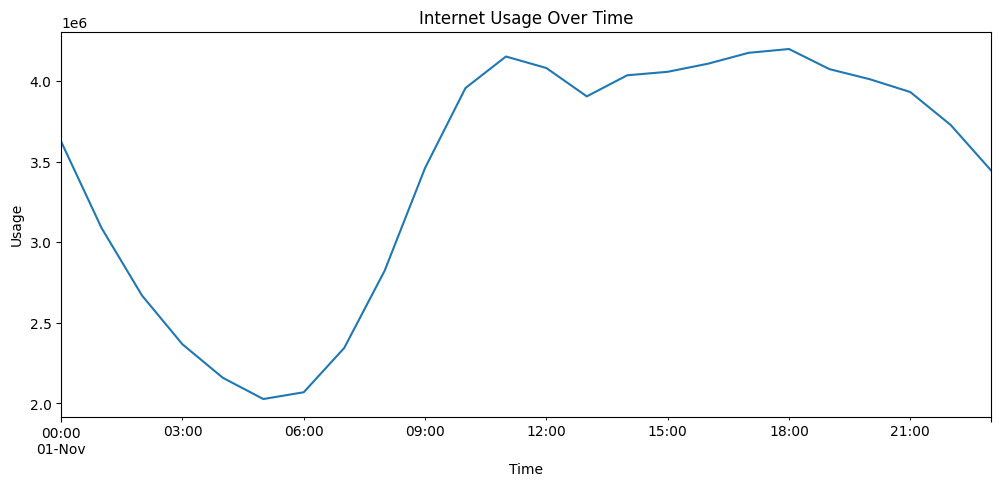

In [17]:
usage_time = df.groupby('timestamp')['internet_usage'].sum()

usage_time.plot(figsize=(12,5))
plt.title("Internet Usage Over Time")
plt.xlabel("Time")
plt.ylabel("Usage")
plt.show()

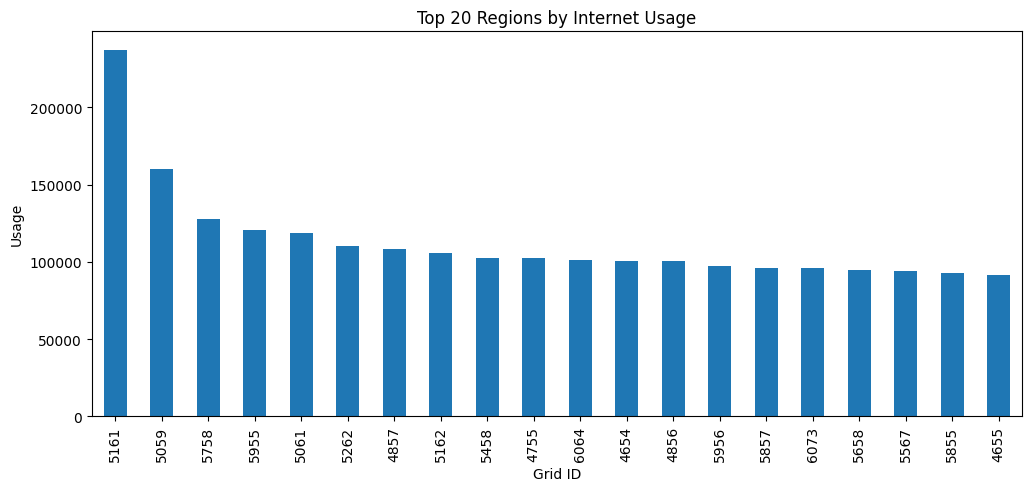

In [18]:
region_usage = df.groupby('grid_id')['internet_usage'].sum().sort_values(ascending=False).head(20)

region_usage.plot(kind='bar', figsize=(12,5))
plt.title("Top 20 Regions by Internet Usage")
plt.xlabel("Grid ID")
plt.ylabel("Usage")
plt.show()

In [19]:
print("Time Range:", df['timestamp'].min(), "to", df['timestamp'].max())

print("\nTop Regions:")
print(region_usage.head())

print("\nPeak Hour:")
print(df.groupby('hour')['internet_usage'].mean().idxmax())

Time Range: 2013-11-01 00:00:00 to 2013-11-01 23:00:00

Top Regions:
grid_id
5161    237230.3882
5059    160148.7705
5758    127441.0282
5955    120642.4426
5061    118359.2517
Name: internet_usage, dtype: float64

Peak Hour:
2013-11-01 00:00:00
